# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [55]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.data import get_contunious_data, get_discrete_data
from python.visualization import (plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour,
plot_fit_scatter2d)

from python.tea import disco_tea

from metrics import calculate_pretreatment_fit

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [56]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [63]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=False,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=False,
    mixture=True
)

result = disco_model.fit()

Initialisiere DiSCo mit Dube-Daten...


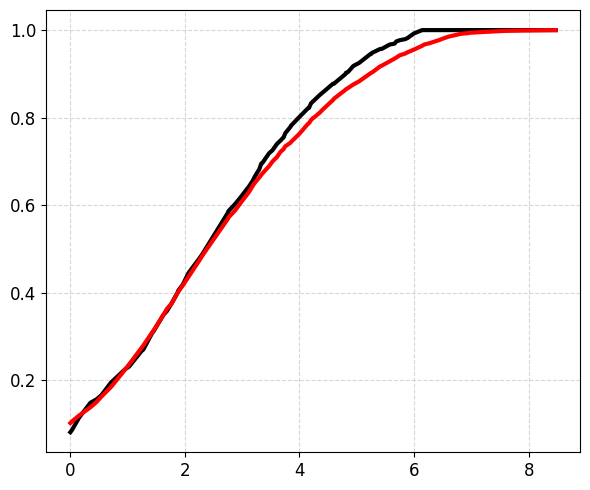

In [64]:
plot_fit_cdf(result, show_controls=False)

In [65]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

39.0    0.186433
20.0    0.133898
13.0    0.114248
26.0    0.102424
45.0    0.059879
dtype: float64

In [66]:
calculate_pretreatment_fit(result)

PreTreatmentFitMetrics(w2=0.10027881665113933, sw1=0.044957218340820344, energy_dist=nan, cov_error=0.02815514341927532, marginal_ks=[0.02341524716306994], marginal_mean_diff=[0.009104777601018198], metrics_per_period={np.float64(1.0): {'w2': 0.11407001001621866, 'sw1': 0.07249808797140168, 'energy_dist': nan, 'cov_error': 0.01219985547065372, 'marginal_ks': [0.03482749418354547], 'marginal_mean_diff': [0.029748530399420048]}, np.float64(2.0): {'w2': 0.06831618334293783, 'sw1': 0.035832977280653835, 'energy_dist': nan, 'cov_error': 0.017581245946191704, 'marginal_ks': [0.020279900252533567], 'marginal_mean_diff': [-0.00036042256189139366]}, np.float64(3.0): {'w2': 0.09194242972404347, 'sw1': 0.04633188090870286, 'energy_dist': nan, 'cov_error': 0.06193963847649142, 'marginal_ks': [0.027294978998382888], 'marginal_mean_diff': [0.013185318887724673]}, np.float64(4.0): {'w2': 0.11869397390303749, 'sw1': 0.03381883130288253, 'energy_dist': nan, 'cov_error': 0.01784532342247358, 'marginal_k


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  Quantile Delta  Std. Error  [95%   Conf. Band] Sig
 2003     0.0   0.9         -0.1271         NaN    NaN          NaN    
 2004     0.0   0.9         -0.2199         NaN    NaN          NaN    


None


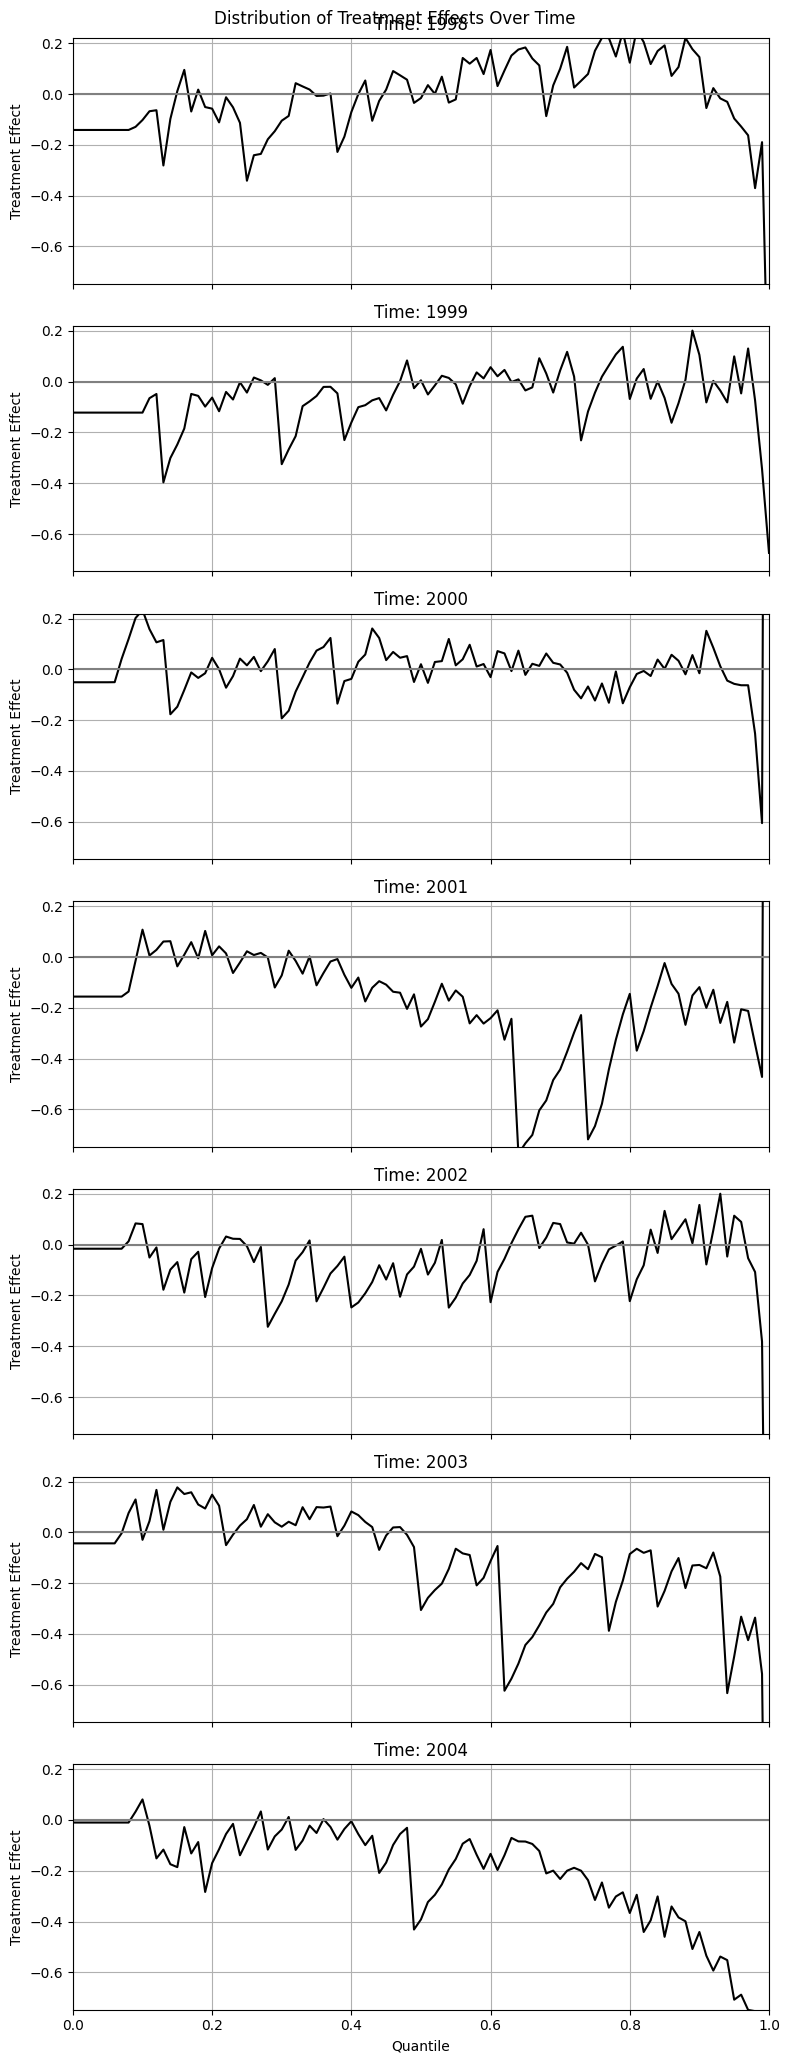

In [67]:
tea_res = disco_tea(result, agg="quantileDiff", graph=True )
print(tea_res.summary())

## Paper replication

### Simulated Data

In [8]:
# Recreation of figure 4 from DiSCo paper
num_controls = 4
sample_size = 1000
seed = 42
synth_df = get_contunious_data(sample_size, num_controls, target_offset=0, dist_control=3, dist_target=4)

fit_synth = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
fit_synth = fit_synth.fit()


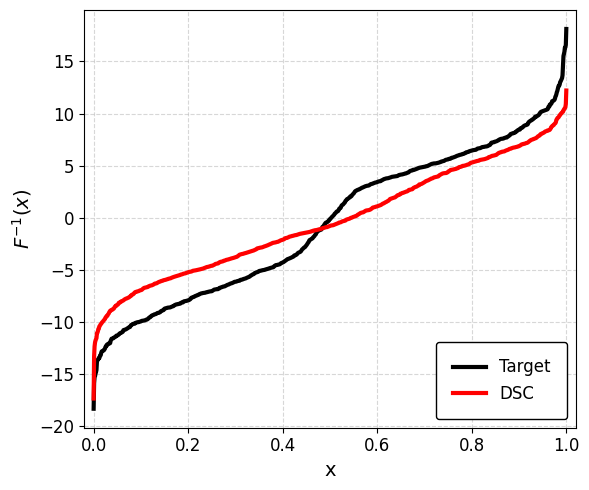

In [9]:
# Get the post-treatment period result to see how it fitted
plot_fit_quantiles(fit_synth, show_controls=False)

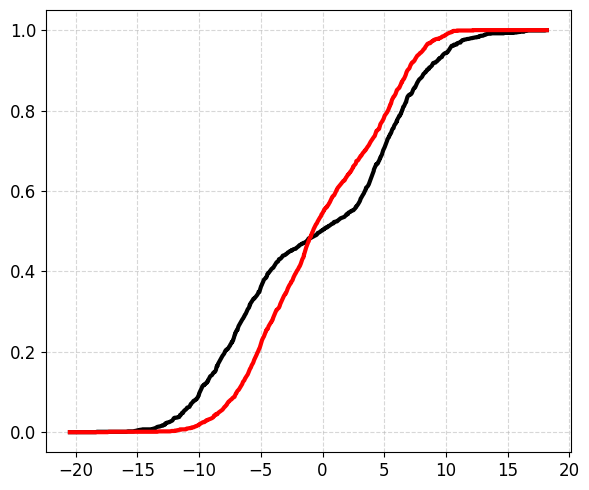

In [10]:
plot_fit_cdf(fit_synth, show_controls=False)

In [11]:
synth_df = get_discrete_data(sample_size, num_controls)

fit_synth_disc = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
)
fit_synth_disc = fit_synth_disc.fit()

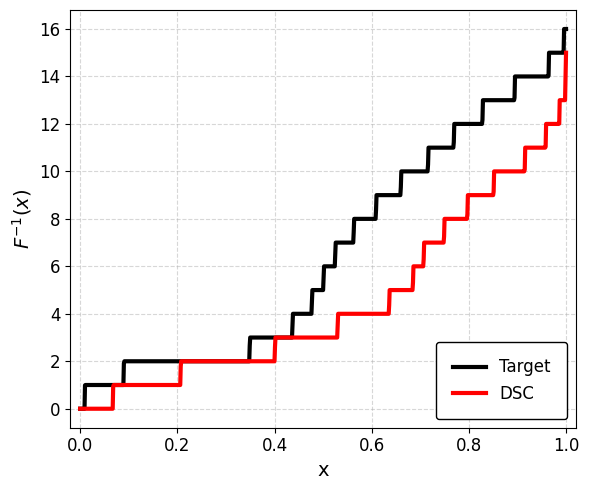

In [12]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth_disc.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth_disc, show_controls=False)
weights = period_res.DiSCo.weights


### Dube Daten aus 2013

In [42]:
dube = pd.read_csv('../datasets/dube_combined.csv')
dube_2013 = dube[dube['year'] == 2013].copy()
dube_2013 = dube_2013.dropna(subset=['faminc', 'age']) 

In [43]:
data = []
for fips, group in dube_2013.groupby('fips'):
    if len(group) < 2000:
        continue # Ignoriere die kleinen states
    group = group.sample(n=2000) # Shuffle und 2000 ziehen
    
    # Pre-treatment (Jahr 1)
    pre = group.iloc[:1000].copy()
    pre['year'] = 1
    
    # Post-treatment (Jahr 2)
    post = group.iloc[1000:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

dube_multi = pd.concat(data, ignore_index=True)
print(f"Number of valid states: {dube_multi['fips'].nunique()}")

Number of valid states: 51


In [44]:
fit_dube_multi = DiSCo(
    df=dube_multi,
    id_col='fips',
    time_col='year',
    y_col=['faminc', 'age'],
    id_col_target=4,       # FIPS = 4 (Beispiel state) als Treatment
    t0=2,                  # Treatment im Jahr 2 (post-treatment)
    M=1000,                # Monte Carlo Draws 
    G=50,                  # Grid Size (Kleiner für multidimensional)
    num_cores=-1,          # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,          # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    mixture=False,
)
fit_dube_multi = fit_dube_multi.fit()

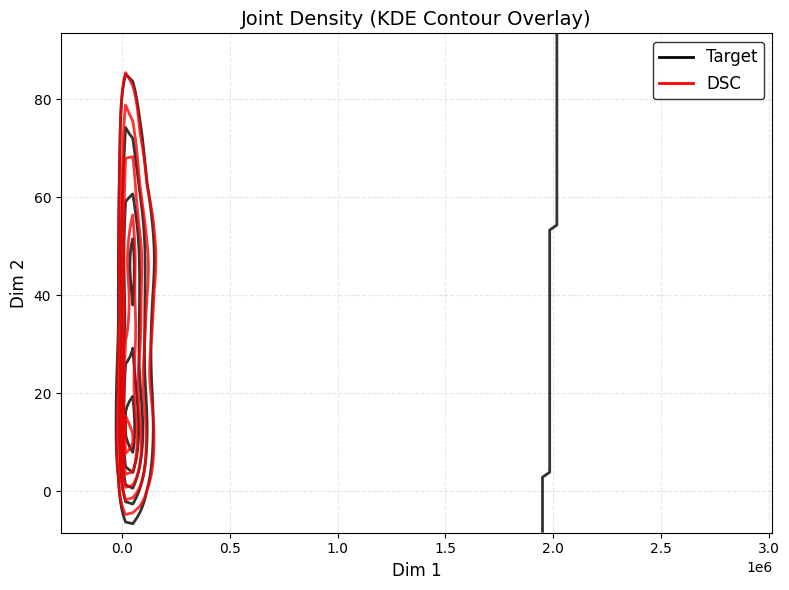

In [ ]:
plot_fit_joint_contour(fit_dube_multi)

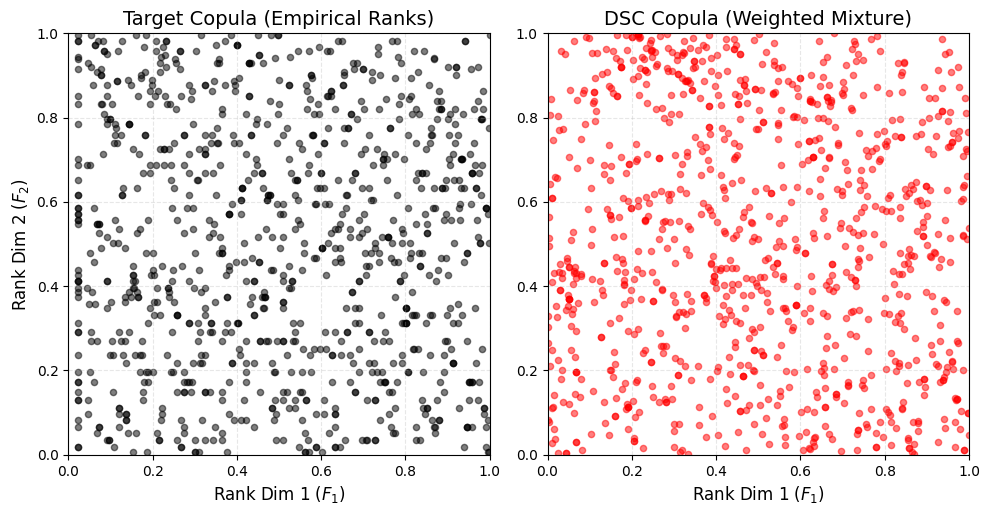

In [ ]:
plot_fit_copula(fit_dube_multi)

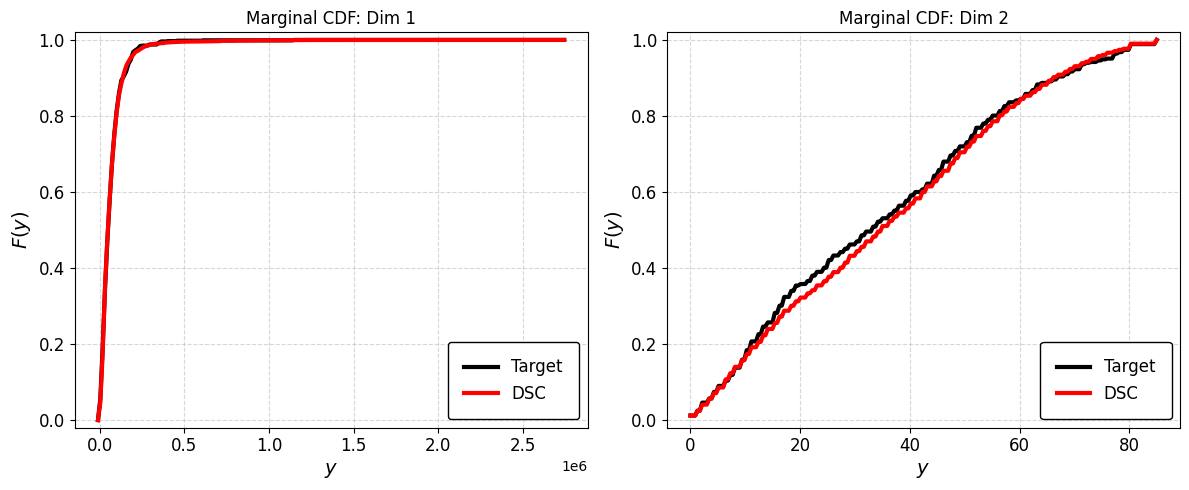

In [ ]:
plot_fit_cdf(fit_dube_multi)

### Medicaid Dataset

In [45]:
medicaid = pd.read_csv('../datasets/medicaid.csv')

In [51]:
medicaid['STATEFIP'].value_counts()

STATEFIP
48    558133
12    403247
37    220842
13    215554
55    147241
47    142015
45    102360
1     100922
20     70020
28     58116
30     22639
46     20263
56     14712
Name: count, dtype: int64

### Simulierte Daten

In [32]:
# Super realistische Schwankungen (nahe der vorgegebenen Baseline)
test_df = get_contunious_data(1000, 100, dim=2, base_corr=0.3, corr_drift=0.6)

#print(test_df[test_df['time_col'] == 9999].groupby('id_col').apply(lambda x: np.corrcoef(x['y_col_1'], x['y_col_2'])[0, 1]))
#print(np.corrcoef(test_df.loc[test_df['time_col'] == 9999, ['y_col_1', 'y_col_2']].values.T)[0,1])

In [33]:
fit_2D_sw = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1','y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    mixture=False
)
fit_2D_sw = fit_2D_sw.fit()

In [34]:
fit_2D_mix = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1','y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    mixture=True
)
fit_2D_mix = fit_2D_mix.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:282: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=100000, eps=1e-6)


In [41]:
np.random.seed(41)

print(calculate_pretreatment_fit(fit_2D_sw))
print(calculate_pretreatment_fit(fit_2D_mix).metrics_per_period[1])

PreTreatmentFitMetrics(w2=3.258175816783022, sw1=1.2539854080451618, energy_dist=nan, cov_error=29.097164794215537, marginal_ks=[0.08349963591629883, 0.10072760187559152], marginal_mean_diff=[0.07644550210328627, 0.06525567738918525], metrics_per_period={np.int64(1): {'w2': 3.258175816783022, 'sw1': 1.2539854080451618, 'energy_dist': nan, 'cov_error': 29.097164794215537, 'marginal_ks': [0.08349963591629883, 0.10072760187559152], 'marginal_mean_diff': [0.07644550210328627, 0.06525567738918525]}})
{'w2': 1.9078156874679377, 'sw1': 0.5280573974400555, 'energy_dist': nan, 'cov_error': 12.679790767823485, 'marginal_ks': [0.036956410904321335, 0.050100795591518366], 'marginal_mean_diff': [0.1644401738148128, -0.22000337568348804]}
